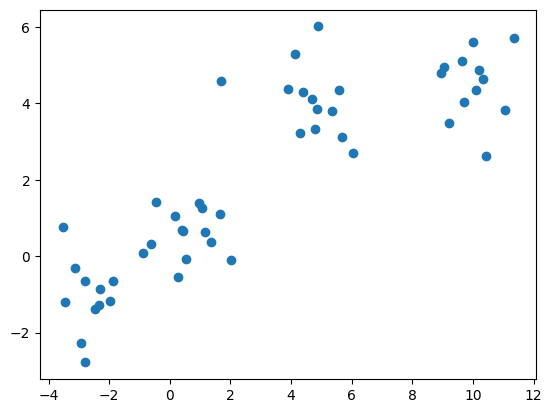

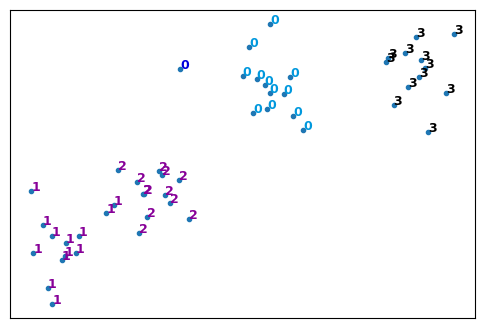

[[0.         0.89221967 0.08362736 ... 0.38011012 0.78910769 0.77496568]
 [0.89221967 0.         0.93347579 ... 0.55895655 0.18458274 0.12494651]
 [0.08362736 0.93347579 0.         ... 0.39635751 0.84286948 0.8202518 ]
 ...
 [0.38011012 0.55895655 0.39635751 ... 0.         0.5119048  0.46018236]
 [0.78910769 0.18458274 0.84286948 ... 0.5119048  0.         0.10318462]
 [0.77496568 0.12494651 0.8202518  ... 0.46018236 0.10318462 0.        ]]


/tmp/ipykernel_3378191/3198003491.py:44: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = hierarchy.linkage(dist_matrix, 'complete')


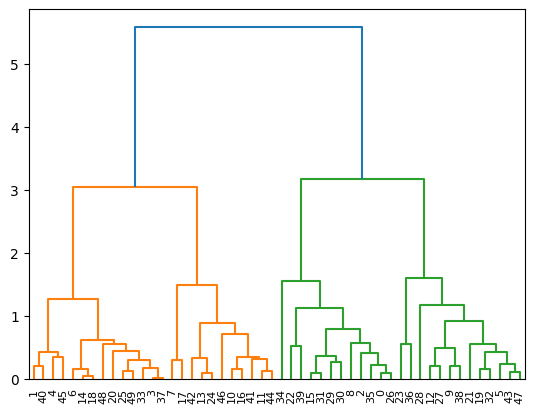

In [4]:
import numpy as np 
import pandas as pd
from scipy import ndimage 
from scipy.cluster import hierarchy 
from scipy.spatial import distance_matrix 
from matplotlib import pyplot as plt 
from sklearn import manifold, datasets 
from sklearn.cluster import AgglomerativeClustering 
from sklearn.datasets import make_blobs 
%matplotlib inline

np.random.seed(0)

X1, y1 = make_blobs(n_samples=50, 
                    centers=[[4,4], [-2, -1], [1, 1], [10,4]], 
                    cluster_std=0.9)

plt.scatter(X1[:, 0], X1[:, 1], marker='o') 

agglom = AgglomerativeClustering(n_clusters = 4, linkage = 'single')

agglom.fit(X1,y1)

plt.figure(figsize=(6,4))

x_min, x_max = np.min(X1, axis=0), np.max(X1, axis=0)

X1 = (X1 - x_min) / (x_max - x_min)

for i in range(X1.shape[0]):
    plt.text(X1[i, 0], X1[i, 1], str(y1[i]),
             color=plt.cm.nipy_spectral(agglom.labels_[i] / 10.),
             fontdict={'weight': 'bold', 'size': 9})
    
plt.xticks([])
plt.yticks([])

plt.scatter(X1[:, 0], X1[:, 1], marker='.')
plt.show()

dist_matrix = distance_matrix(X1,X1) 
print(dist_matrix)

Z = hierarchy.linkage(dist_matrix, 'complete')
dendro = hierarchy.dendrogram(Z)

Shape of dataset:  (159, 16)
Shape of dataset before cleaning:  2544
Shape of dataset after cleaning:  1872


/tmp/ipykernel_3378191/2672043557.py:35: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = hierarchy.linkage(D, 'ward')


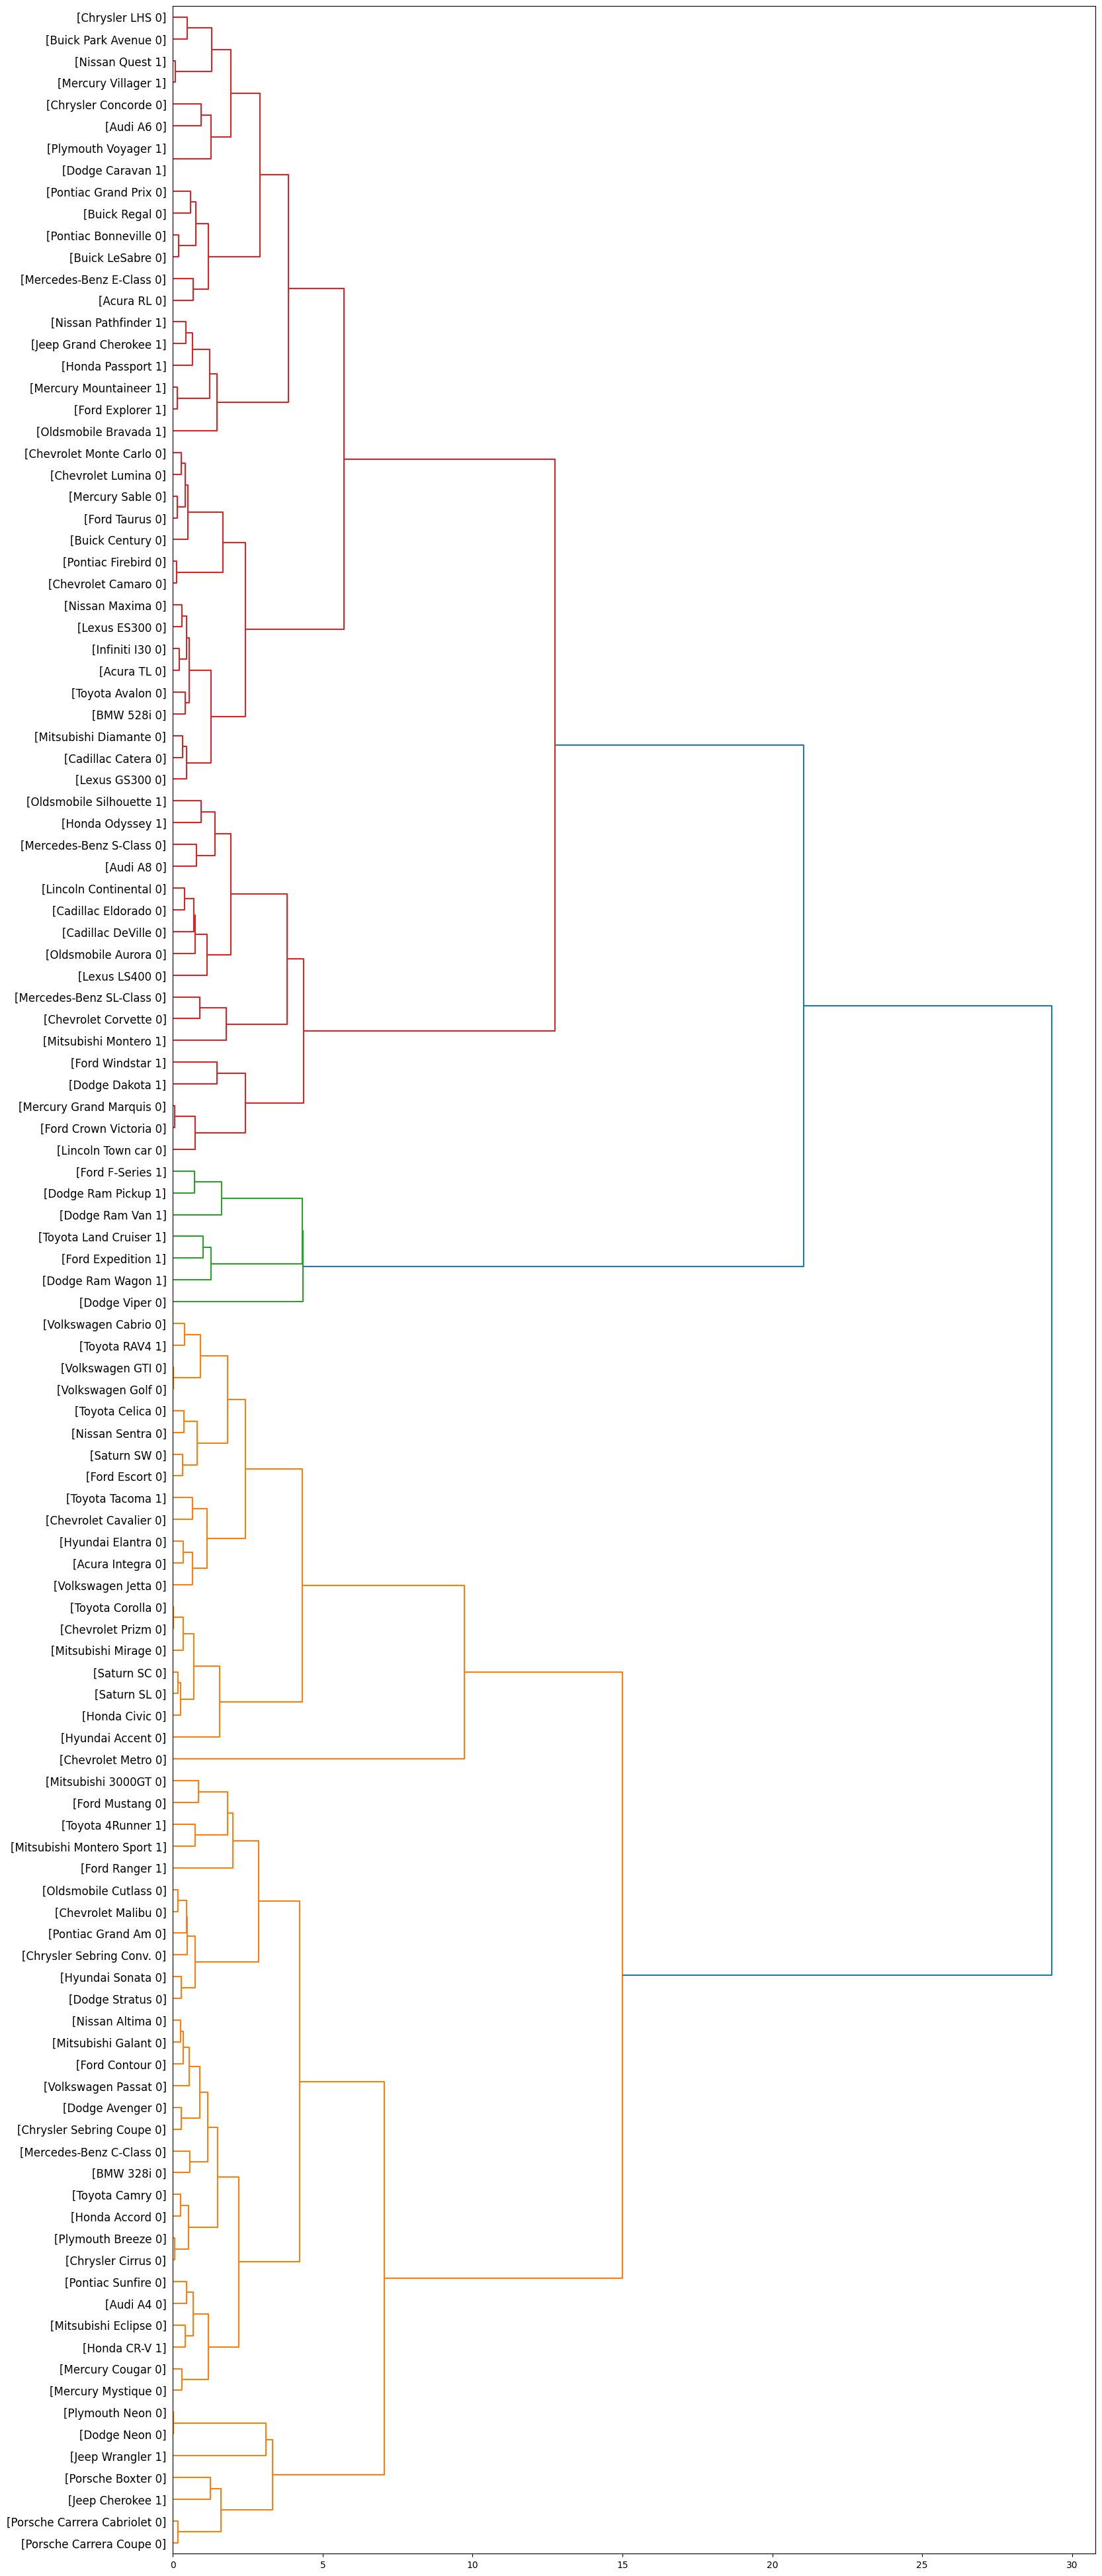

In [11]:
pdf = pd.read_csv('/home/jupyter/work/data/cars_clus.csv')
print ("Shape of dataset: ", pdf.shape)
pdf.head()

print ("Shape of dataset before cleaning: ", pdf.size)
pdf[[ 'sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales']] = pdf[['sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales']].apply(pd.to_numeric, errors='coerce')
pdf = pdf.dropna()
pdf = pdf.reset_index(drop=True)
print ("Shape of dataset after cleaning: ", pdf.size)
pdf.head(5)

featureset = pdf[['engine_s',  'horsepow', 'wheelbas', 'width', 
                  'length', 'curb_wgt', 'fuel_cap', 'mpg']]

from sklearn.preprocessing import MinMaxScaler
x = featureset.values #returns a numpy array
min_max_scaler = MinMaxScaler()
feature_mtx = min_max_scaler.fit_transform(x)
feature_mtx [0:5]

import scipy
leng = feature_mtx.shape[0]
D = np.zeros([leng,leng])
for i in range(leng):
    for j in range(leng):
        D[i,j] = scipy.spatial.distance.euclidean(feature_mtx[i], feature_mtx[j])
        
        
import pylab
import scipy.cluster.hierarchy
Z = hierarchy.linkage(D, 'ward')

from scipy.cluster.hierarchy import fcluster
max_d = 3
clusters = fcluster(Z, max_d, criterion='distance')
clusters

from scipy.cluster.hierarchy import fcluster
k = 5
clusters = fcluster(Z, k, criterion='maxclust')
clusters

fig = pylab.figure(figsize=(18,50))
def llf(id):
    return '[%s %s %s]' % (pdf['manufact'][id], pdf['model'][id], 
                           int(float(pdf['type'][id])) )
    
dendro = hierarchy.dendrogram(Z,  leaf_label_func=llf, leaf_rotation=0, 
                              leaf_font_size =12, orientation = 'right')

In [ ]:
dist_matrix = distance_matrix(feature_mtx,feature_mtx) 
agglom = AgglomerativeClustering(n_clusters = 6, linkage = 'complete')
agglom.fit(feature_mtx)
agglom.labels_

pdf['cluster_'] = agglom.labels_
pdf.head()

import matplotlib.cm as cm
n_clusters = max(agglom.labels_)+1
colors = cm.rainbow(np.linspace(0, 1, n_clusters))
cluster_labels = list(range(0, n_clusters))

plt.figure(figsize=(16,14))

for color, label in zip(colors, cluster_labels):
    subset = pdf[pdf.cluster_ == label]
    for i in subset.index:
            plt.text(subset.horsepow[i], subset.mpg[i], 
                     str(subset['model'][i]), rotation=25) 
    plt.scatter(subset.horsepow, subset.mpg, s= subset.price*10, 
                c=color, label='cluster'+str(label),alpha=0.5)
plt.legend()
plt.title('Clusters')
plt.xlabel('horsepow')
plt.ylabel('mpg')

pdf.groupby(['cluster_','type'])['cluster_'].count()

agg_cars = pdf.groupby(['cluster_','type'])[['horsepow','engine_s','mpg','price']].mean()
agg_cars

plt.figure(figsize=(16,10))
for color, label in zip(colors, cluster_labels):
    subset = agg_cars.loc[(label,),]
    for i in subset.index:
        plt.text(subset.loc[i][0]+5, subset.loc[i][2], 'type='+str(int(i)) + ',\
        price='+str(int(subset.loc[i][3]))+'k')
    plt.scatter(subset.horsepow, subset.mpg, s=subset.price*20, c=color, 
                label='cluster'+str(label))
plt.legend()
plt.title('Clusters')
plt.xlabel('horsepow')
plt.ylabel('mpg')